In [50]:
import os
import sys
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import random
import numpy as np

# Add the directory containing 'hamiltonian' to the Python path
sys.path.append('/home/scostagonza/Documents/ETC/Effective-Topological-Coverage-ETC/examples/etc_utils')

from etc.hamiltonian import Hamiltonian

In [51]:
def random_subsets(nodes, k, iters, seed=1):
    """
    Yield `iters` random subsets of size `k` from the list of `nodes`.

    Parameters
    ----------
    nodes : list
        List of nodes to sample from.
    k : int
        Size of each subset.
    iters : int
        Number of subsets to generate.
    seed : int
        Random seed for reproducibility.

    Yields
    ------
    list of int
        Randomly sampled indices (or node IDs).
    """
    rng = random.Random(seed)
    nodes = list(nodes)
    for _ in range(iters):
        yield rng.sample(nodes, k)

In [52]:
graph_dir = "/home/scostagonza/Documents/ETC/Effective-Topological-Coverage-ETC/examples/data" 
graph_files = [f for f in os.listdir(graph_dir) if f.endswith(".gml")]

print(f"Found {len(graph_files)} graphs:")
for f in graph_files:
    print(" -", f)

Found 5 graphs:
 - Complete_Bipartite_K50_50.gml
 - Random_Partition_communities.gml
 - Circular_Laddern100.gml
 - Regularn50_d6.gml
 - Erdos-Renyin80_p0.05.gml


In [53]:
def evaluate_graph(G, name, k, iters=300, seed=1):
    from etc.hamiltonian import Hamiltonian
    H_obj = Hamiltonian(G)
    A = np.triu(nx.to_numpy_array(G))
    Dinv2 = H_obj.Dinv2_triu
    nodes = H_obj.nodes
    mu = H_obj.mu_density_aware(G=G)
    gamma = H_obj.gamma_balancer(mu=mu)

    Hs, T1s, T2s = [], [], []
    rng = np.random.default_rng(seed)
    n = len(nodes)

    for _ in range(iters):
        S_idx = rng.choice(n, size=k, replace=False)
        h, t1, t2 = H_obj.compute(S_idx, mu=mu, gamma=gamma)
        Hs.append(abs(h))
        T1s.append(abs(t1))
        T2s.append(t2)

    Hs = np.array(Hs)
    H_norm = (Hs - Hs.min()) / (Hs.max() - Hs.min())

    return {
        "graph": name,
        "n": n,
        "e": G.number_of_edges(),
        "k": k,
        "mu": mu,
        "gamma": gamma,
        "H_mean": Hs.mean(),
        "H_std": Hs.std(),
        "H_min": Hs.min(),
        "H_max": Hs.max(),
        "T1_mean": np.mean(T1s),
        "T2_mean": np.mean(T2s),
        "H_norm_mean": H_norm.mean(),
        "H_norm_std": H_norm.std()
    }



In [54]:
k = 30
results = []

for fname in graph_files:
    path = os.path.join(graph_dir, fname)
    G = nx.read_gml(path)
    G = nx.convert_node_labels_to_integers(G)

    if (len(G) >= k) and (len(G) < 300):
        res = evaluate_graph(G=G, name=fname.replace(".gml", ""), k=k)
        results.append(res)
    else:
        print(f"Skipping graph {fname} as it has fewer nodes ({len(G)}) than k ({k}).")

df = pd.DataFrame(results)

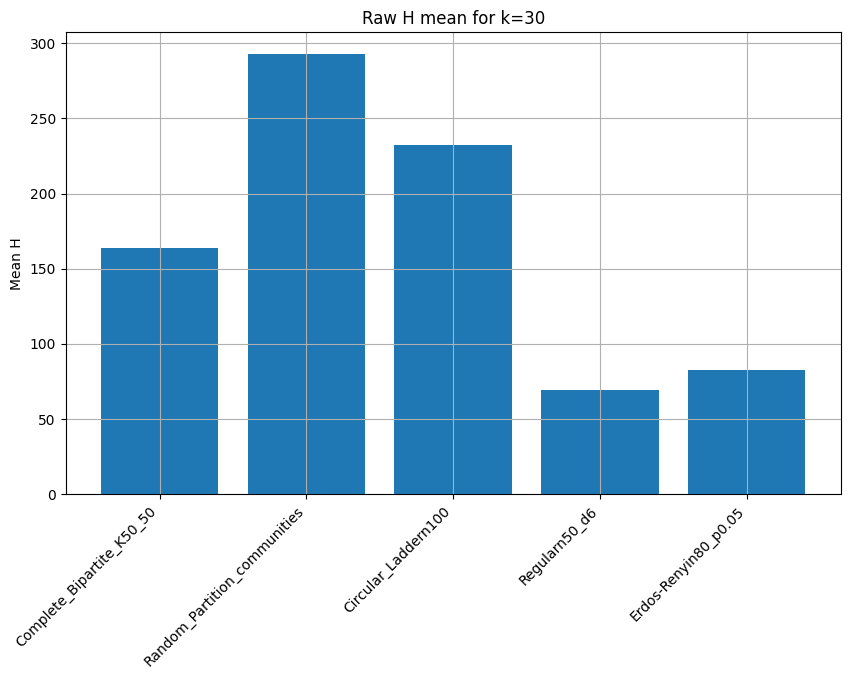

In [55]:
plt.figure(figsize=(10,6))
plt.bar(df["graph"], df["H_mean"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean H")
plt.title(f"Raw H mean for k={k}")
plt.grid(True)
plt.show()

In [56]:
def sample_H_values_for_graph(G_or_path, k, samples=1000, seed=42, distance_matrix=None, abs_values=True):
    """
    Return a list of sampled H values for a single graph.

    Parameters
    ----------
    G_or_path : networkx.Graph or str
        Either an already-loaded NetworkX Graph or a path to a .gml file.
    k : int
        Subset size to sample.
    samples : int
        Number of random subsets to sample.
    seed : int
        RNG seed for reproducibility.
    distance_matrix : array-like or None
        Optional precomputed distance matrix to pass to Hamiltonian (if your Hamiltonian accepts it).
    abs_values : bool
        If True, return abs(h) for each sample; otherwise return raw h.

    Returns
    -------
    list[float]
        List of sampled H values (length <= samples).
    """
    # load graph if a path was given
    if isinstance(G_or_path, str):
        if not os.path.exists(G_or_path):
            raise FileNotFoundError(f"Graph file not found: {G_or_path}")
        G = nx.read_gml(G_or_path)
        G = nx.convert_node_labels_to_integers(G)
    else:
        G = G_or_path

    n = G.number_of_nodes()
    if k > n:
        raise ValueError(f"k ({k}) is larger than number of nodes in G ({n})")

    # instantiate Hamiltonian
    # If your Hamiltonian constructor signature differs, adapt this line accordingly.
    if distance_matrix is not None:
        H_obj = Hamiltonian(G, distance_matrix=distance_matrix)
    else:
        H_obj = Hamiltonian(G)

    mu = H_obj.mu_density_aware(G=G)
    gamma = H_obj.gamma_balancer(mu=mu)

    rng = np.random.default_rng(seed)
    h_values = []
    num_nodes = len(H_obj.nodes) if hasattr(H_obj, "nodes") else n

    for _ in range(samples):
        S_idx = rng.choice(num_nodes, size=k, replace=False)
        res = H_obj.compute(S_idx, mu=mu, gamma=gamma)
        # handle either numeric return or tuple (h, t1, t2)
        h = res[0] if isinstance(res, (tuple, list)) else res
        h_values.append(abs(h) if abs_values else h)

    return h_values

In [31]:
df

,graph,n,e,k,mu,gamma,H_mean,H_std,H_min,H_max,T1_mean,T2_mean,H_norm_mean,H_norm_std
0,WS_beta1.0,50,200,30,0.836735,1.469388,48.582177,13.915820,13.142857,92.693878,59.553197,108.135374,0.445492,0.174930
1,Balanced_Treer3_h3,40,39,30,0.950000,1.800000,25.036085,6.829802,5.709000,44.858000,20.668833,45.704918,0.493680,0.174457
2,Complete_Bipartite_K50_50,100,2500,30,0.494949,2.020202,163.860269,48.283849,38.545455,271.878788,108.393939,272.254209,0.537063,0.206931
3,Random_Partition_communities,60,489,30,0.723729,4.420339,292.656774,47.882114,176.914689,415.666290,87.942701,380.599475,0.484780,0.200552
4,Circular_Laddern100,100,150,30,0.969697,20.484848,231.960926,46.777287,79.793464,367.999013,13.058586,245.019512,0.527982,0.162305
5,Powerlaw-Cluster,50,96,30,0.921633,1.959184,62.346693,14.905050,23.379592,103.064762,31.197265,93.543958,0.489013,0.187049
6,WS_beta0.2,50,200,30,0.836735,2.612245,113.002525,18.327447,60.535147,160.628118,59.614558,172.617082,0.524186,0.183104
7,d-Regularn400_d6,50,150,30,0.877551,1.959184,69.570816,14.776104,25.816327,113.312925,46.700340,116.271156,0.500071,0.168876
8,Core-Periphery,120,340,30,0.952381,2.333333,69.139782,14.275752,30.736825,110.022063,19.558730,88.698512,0.484365,0.180056
9,d-Regularn50_d6,50,150,30,0.877551,1.959184,69.570816,14.776104,25.816327,113.312925,46.700340,116.271156,0.500071,0.168876


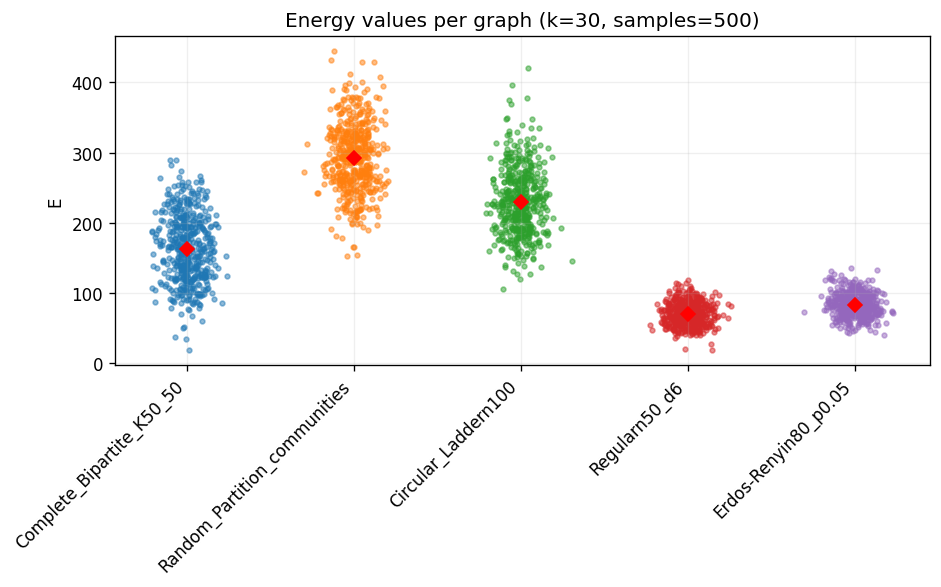

In [58]:
# Scatter plot of absolute H values per graph with per-graph mean
all_vals = {}
samples_per_graph = 500
k_sample = k  # use same k as before
for fname in graph_files:
    path = os.path.join(graph_dir, fname)
    G = nx.read_gml(path)
    G = nx.convert_node_labels_to_integers(G)
    if len(G) < k_sample:
        continue
    H_obj = Hamiltonian(G)
    mu = H_obj.mu_density_aware(G=G)
    gamma = H_obj.gamma_balancer(mu=mu)
    n = len(H_obj.nodes)
    rng = np.random.default_rng(42)
    vals = []
    for _ in range(samples_per_graph):
        S_idx = rng.choice(n, size=k_sample, replace=False)
        h, _, _ = H_obj.compute(S_idx, mu=mu, gamma=gamma)
        vals.append(abs(h))
    all_vals[fname.replace('.gml','')] = vals

# Prepare plot data
names = list(all_vals.keys())
plt.figure(figsize=(max(8, len(names)*0.6), 5), dpi=120)
positions = np.arange(len(names))
for i, name in enumerate(names):
    vals = np.array(all_vals[name])
    if vals.size == 0:
        continue
    # jitter x positions for scatter
    x = np.random.normal(loc=positions[i], scale=0.08, size=len(vals))
    plt.scatter(x, vals, alpha=0.5, s=8)
    # mean marker
    plt.plot(positions[i], vals.mean(), marker='D', color='red')

plt.xticks(positions, names, rotation=45, ha='right')
plt.ylabel('E')
plt.title(f'Energy values per graph (k={k_sample}, samples={samples_per_graph})')
plt.grid(alpha=0.2)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig(os.path.join('figures','H_scatter_per_graph.png'), dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# Build and save H samples for all graphs using the sampling function
import pickle
from etc.hamiltonian import Hamiltonian
import networkx as nx
import numpy as np

def sample_H_values_for_graph(G_or_path, k, samples=500, seed=42, abs_values=True):
    # load graph if path provided
    if isinstance(G_or_path, str):
        G = nx.read_gml(G_or_path)
        G = nx.convert_node_labels_to_integers(G)
    else:
        G = G_or_path
    n = G.number_of_nodes()
    if k > n:
        raise ValueError(f'k ({k}) is larger than number of nodes in G ({n})')

    # instantiate Hamiltonian (adapt if your constructor differs)
    H_obj = Hamiltonian(G)
    mu = H_obj.mu_density_aware(G=G)
    gamma = H_obj.gamma_balancer(mu=mu)

    rng = np.random.default_rng(seed)
    h_values = []
    num_nodes = len(H_obj.nodes) if hasattr(H_obj, 'nodes') else n
    for _ in range(samples):
        S_idx = rng.choice(num_nodes, size=k, replace=False)
        res = H_obj.compute(S_idx, mu=mu, gamma=gamma)
        h = res[0] if isinstance(res, (tuple, list)) else res
        h_values.append(abs(h) if abs_values else h)
    return h_values

# Apply to all graphs and save results
k_apply = k
samples_per_graph = 500
all_H_samples = {}
for fname in graph_files:
    path = os.path.join(graph_dir, fname)
    try:
        h_list = sample_H_values_for_graph(path, k_apply, samples=samples_per_graph, seed=42)
    except Exception as e:
        print(f'Error sampling {fname}: {e}')
        h_list = []
    all_H_samples[fname.replace('.gml','')] = h_list


Error sampling Barbellc10__p5.gml: k (30) is larger than number of nodes in G (25)
Error sampling Barbellc25__p5.gml: k (30) is larger than number of nodes in G (25)


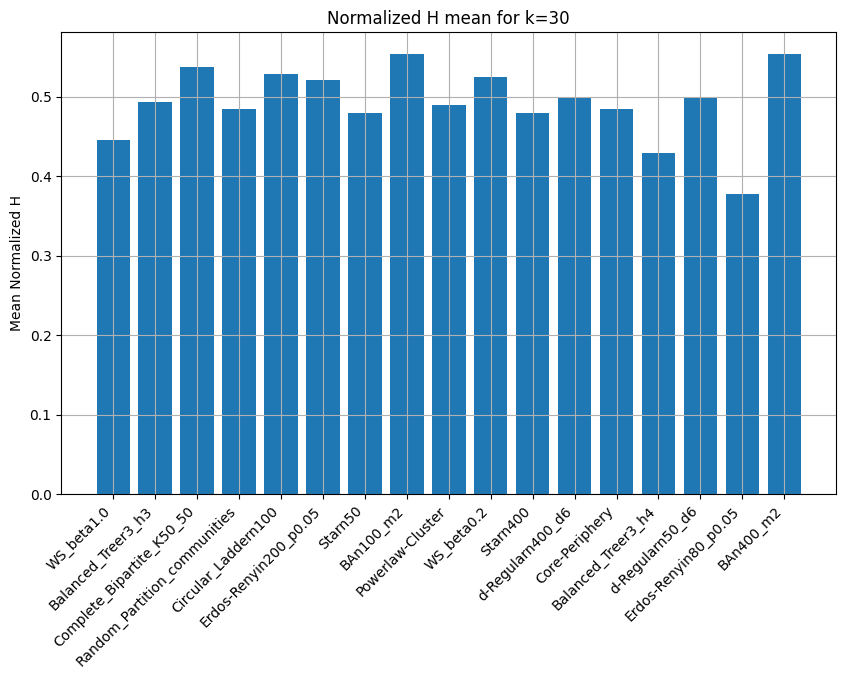

In [40]:
plt.figure(figsize=(10,6))
plt.bar(df["graph"], df["H_norm_mean"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Normalized H")
plt.title(f"Normalized H mean for k={k}")
plt.grid(True)
plt.show()

In [95]:
import networkx.algorithms.community as nxcom

def mean_pairwise_distance(G, S,distance_matrix=None):
    if distance_matrix is not None:
        nodes = list(S)
        total = 0
        c = 0
        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                total += distance_matrix[nodes[i], nodes[j]]
                c += 1
        return total / c if c else 0.0
    else:
        dist = dict(nx.all_pairs_shortest_path_length(G))
        nodes = list(S)
        total = 0
        c = 0
        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                total += dist[nodes[i]][nodes[j]]
                c += 1
    return total / c if c else 0.0

def communities_touched(G, S):
    parts = list(nxcom.label_propagation_communities(G))
    label = {u: i for i, comm in enumerate(parts) for u in comm}
    return len(set(label[u] for u in S if u in label))

In [81]:
G = nx.barabasi_albert_graph(400, 2)
nodes = list(G.nodes)
S = random.sample(nodes, 30)
print("Mean pairwise distance in S:", mean_pairwise_distance(G, S))
print("Communities touched by S:", communities_touched(G, S))

Mean pairwise distance in S: 3.9701149425287356
Communities touched by S: 20


In [66]:
k_values = [10, 20, 30, 40]
results = []
H_obj = Hamiltonian(G)
mu = H_obj.mu_density_aware(G=G)
gamma = H_obj.gamma_balancer(mu=mu)

for k in k_values:
    for S_idx in random_subsets(nodes, k, iters=200, seed=42):
        h_val, t1, t2 = H_obj.compute(S_idx, mu=mu, gamma=gamma)
        mpd = mean_pairwise_distance(G, S_idx)
        ct = communities_touched(G, S_idx)

        results.append({
            "k": k,
            "H": abs(h_val),
            "T1": t1,
            "T2": t2,
            "mean_pairwise_dist": mpd,
            "communities": ct
        })

df = pd.DataFrame(results)

In [67]:
from scipy.stats import spearmanr

print("Correlation between H and MPD:", spearmanr(df["H"], df["mean_pairwise_dist"]).correlation)
print("Correlation between H and communities:", spearmanr(df["H"], df["communities"]).correlation)


Correlation between H and MPD: -0.023152342516108357
Correlation between H and communities: 0.8350623883911591


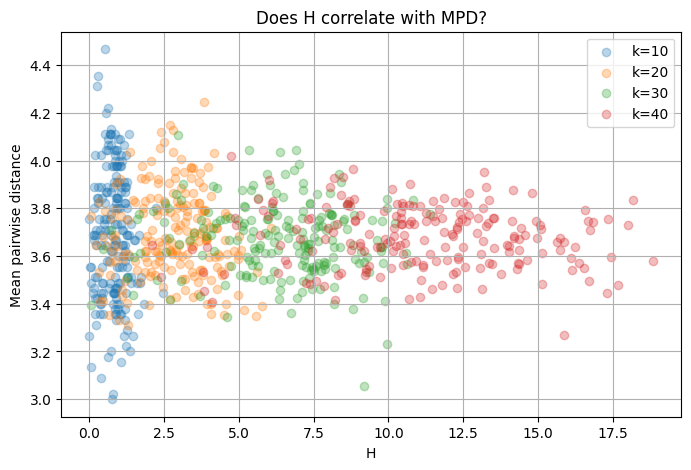

In [68]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
for k in k_values:
    df_k = df[df["k"] == k]
    plt.scatter(df_k["H"], df_k["mean_pairwise_dist"], alpha=0.3, label=f"k={k}")
plt.xlabel("H")
plt.ylabel("Mean pairwise distance")
plt.legend()
plt.title("Does H correlate with MPD?")
plt.grid(True)
plt.show()

In [90]:
from pathlib import Path
notebook_dir = Path().resolve()
project_root = notebook_dir.parent
gml_path = project_root / "data" / "resources" / "generated" / "modified_graph.gml"
D = np.load(f"{project_root}/data/resources/generated/dist_matrix.npy")

Try on Human1

In [83]:
G = nx.read_gml(gml_path)
nodes = list(G.nodes)
S = random.sample(nodes, 300)
print("Mean pairwise distance in S:", mean_pairwise_distance(G, S))
print("Communities touched by S:", communities_touched(G, S))

Mean pairwise distance in S: 7.34659977703456
Communities touched by S: 172


In [84]:
nodes = range(G.number_of_nodes())

In [96]:
k_values = [100, 200, 300, 400]
results = []
H_obj = Hamiltonian(G, distance_matrix=D)
mu = H_obj.mu_density_aware(G=G)
gamma = H_obj.gamma_balancer(mu=mu)

for k in k_values:
    for S_idx in random_subsets(nodes, k, iters=200, seed=42):
        h_val, t1, t2 = H_obj.compute(S_idx, mu=mu, gamma=gamma)
        mpd = mean_pairwise_distance(G, S_idx,distance_matrix=D)
        ct = communities_touched(G, S_idx)

        results.append({
            "k": k,
            "H": abs(h_val),
            "T1": t1,
            "T2": t2,
            "mean_pairwise_dist": mpd,
            "communities": ct
        })

df = pd.DataFrame(results)

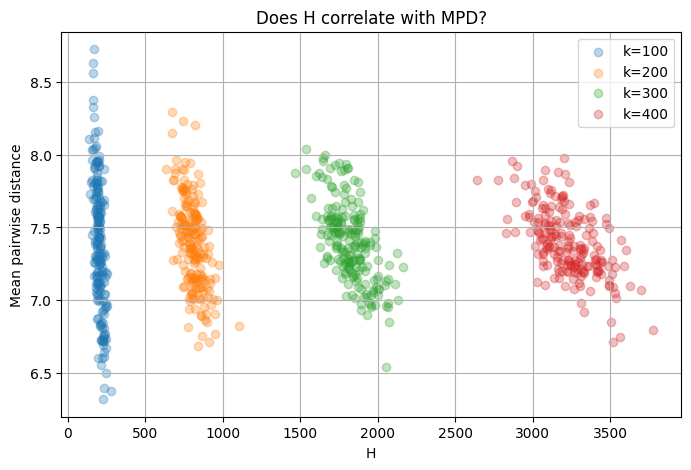

In [97]:
plt.figure(figsize=(8,5))
for k in k_values:
    df_k = df[df["k"] == k]
    plt.scatter(df_k["H"], df_k["mean_pairwise_dist"], alpha=0.3, label=f"k={k}")
plt.xlabel("H")
plt.ylabel("Mean pairwise distance")
plt.legend()
plt.title("Does H correlate with MPD?")
plt.grid(True)
plt.show()

In [98]:
from scipy.stats import spearmanr
rho1 = spearmanr(df["H"], df["mean_pairwise_dist"]).correlation
rho2 = spearmanr(df["H"], df["communities"]).correlation

/tmp/ipykernel_232891/513362900.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho2 = spearmanr(df["H"], df["communities"]).correlation


<Axes: xlabel='k', ylabel='H'>

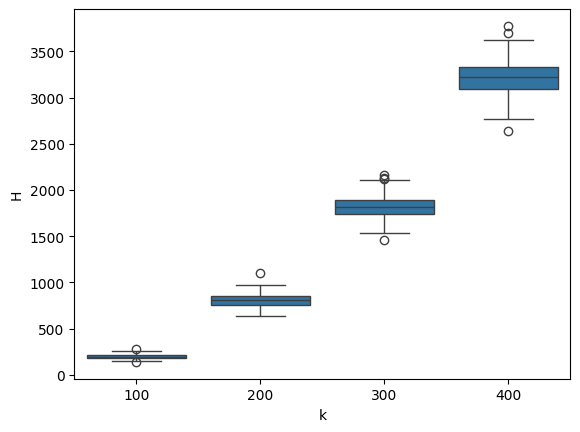

In [99]:
import seaborn as sns
sns.boxplot(data=df, x="k", y="H")

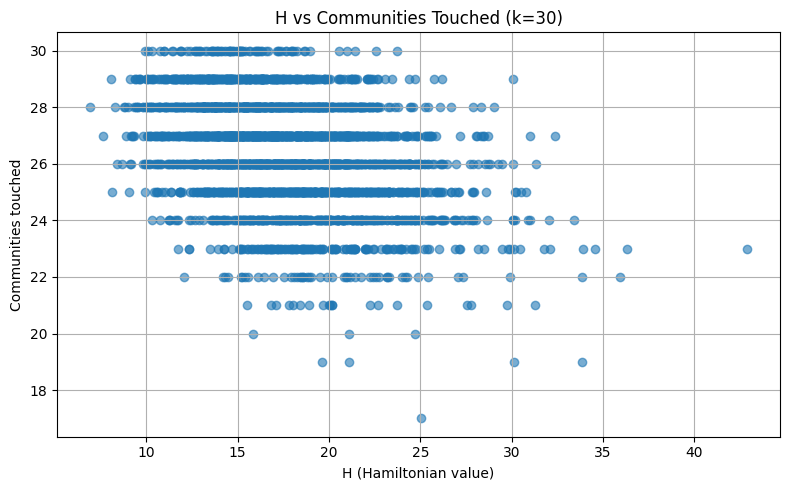

In [122]:
# Parameters
k = 30
iters = 3000
H_vals = []
comm_vals = []

for S in random_subsets(nodes, k, iters=iters, seed=42):
    h_val = abs(H_obj.compute(S, mu=mu, gamma=gamma)[0])
    H_vals.append(h_val)
    df = pd.DataFrame(list(G.nodes()))
    S_idx = df[df.index.isin(S)].values.flatten()
    comm_vals.append(communities_touched(G, S_idx))

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(H_vals, comm_vals, alpha=0.6)
plt.xlabel("H (Hamiltonian value)")
plt.ylabel("Communities touched")
plt.title(f"H vs Communities Touched (k={k})")
plt.grid(True)
plt.tight_layout()
plt.show()

In [74]:
corr = spearmanr(-1 * np.array(H_vals), np.array(comm_vals)).correlation
print(f"Spearman correlation: {corr:.3f}")

Spearman correlation: -0.092


In [ ]:
def get_min_max_H_subsets(G, k=30, iters=300, seed=42):
    A, Dinv2, nodes, idx = precompute(G)
    mu = mu_density_aware(G)
    gamma = gamma_balancer(G, mu=mu)

    rng = np.random.default_rng(seed)
    n = len(nodes)
    
    best_subset = None
    worst_subset = None
    H_min = np.inf
    H_max = -np.inf

    for _ in range(iters):
        S_idx = rng.choice(n, size=k, replace=False)
        h_val, _, _ = H(A, Dinv2, S_idx, mu=mu, gamma=gamma)

        if h_val < H_min:
            H_min = h_val
            best_subset = S_idx

        if h_val > H_max:
            H_max = h_val
            worst_subset = S_idx

    return list(best_subset), list(worst_subset), H_min, H_max

Saved figure to figures/H_scatter_positive_per_graph_k30_s500.png


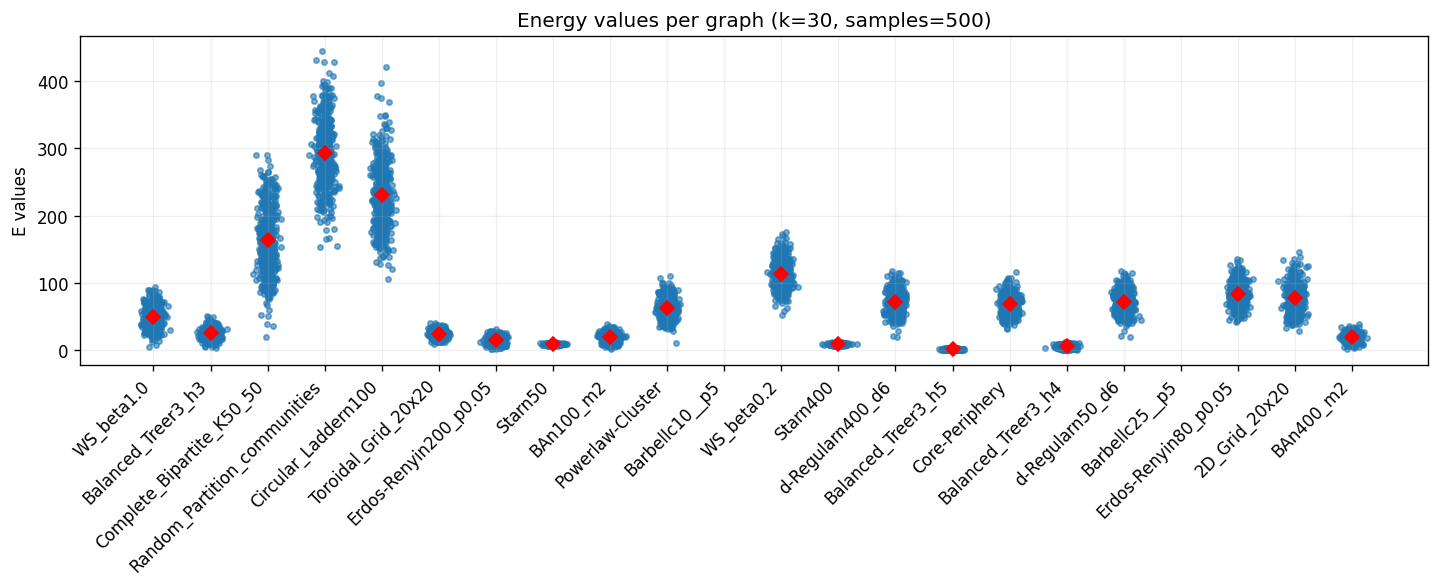

In [19]:
# Sample positive H values for each graph and plot scatter (x=graph names, y=H>0)
import os
import numpy as np
import matplotlib.pyplot as plt
from etc.hamiltonian import Hamiltonian
import networkx as nx

# Parameters: adjust as needed
k_sample = 30
samples_per_graph = 500
seed = 42

def sample_positive_H_for_graph(G_or_path, k, samples=500, seed=42):
    # Load graph if path provided
    if isinstance(G_or_path, str):
        G = nx.read_gml(G_or_path)
        G = nx.convert_node_labels_to_integers(G)
    else:
        G = G_or_path
    n = G.number_of_nodes()
    if k > n:
        return []

    # instantiate Hamiltonian (adapt if your constructor differs)
    H_obj = Hamiltonian(G)
    try:
        mu = H_obj.mu_density_aware(G=G)
        gamma = H_obj.gamma_balancer(mu=mu)
    except Exception:
        mu, gamma = None, None

    rng = np.random.default_rng(seed)
    num_nodes = len(H_obj.nodes) if hasattr(H_obj, 'nodes') else n
    vals = []
    for _ in range(samples):
        S_idx = rng.choice(num_nodes, size=k, replace=False)
        res = H_obj.compute(S_idx, mu=mu, gamma=gamma)
        h = res[0] if isinstance(res, (tuple, list)) else res
        if h is None:
            continue
        if h > 0:
            vals.append(h)
    return vals

# Collect positive H values for each graph
all_positive = {}
for fname in graph_files:
    path = os.path.join(graph_dir, fname)
    try:
        vals = sample_positive_H_for_graph(path, k_sample, samples=samples_per_graph, seed=seed)
    except Exception as e:
        print(f'Error sampling {fname}: {e}')
        vals = []
    all_positive[fname.replace('.gml','')] = vals

# Prepare plotting
names = list(all_positive.keys())
positions = np.arange(len(names))
plt.figure(figsize=(max(8, len(names) * 0.55), 5), dpi=120)
for i, name in enumerate(names):
    vals = np.array(all_positive[name])
    if vals.size == 0:
        continue
    x = np.random.normal(loc=positions[i], scale=0.08, size=len(vals))
    plt.scatter(x, vals, alpha=0.6, s=10, color='C0')
    plt.plot(positions[i], vals.mean(), marker='D', color='red')

plt.xticks(positions, names, rotation=45, ha='right')
plt.ylabel('E values')
plt.title(f'Energy values per graph (k={k_sample}, samples={samples_per_graph})')
plt.grid(alpha=0.2)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
outp = os.path.join('figures', f'H_scatter_positive_per_graph_k{k_sample}_s{samples_per_graph}.png')
plt.savefig(outp, dpi=300, bbox_inches='tight')
print('Saved figure to', outp)
plt.show()

In [ ]:
all_positive = all_positive[
    'WS_beta1.0','Balanced_Treer3_h3', 'Complete_Bipartite_K50_50', 'Random_Partition_communities', 'Circular_Laddern100']

{'WS_beta1.0': [64.20408163265307,
  54.40816326530612,
  42.408163265306136,
  66.61224489795917,
  27.795918367346943,
  39.14285714285714,
  48.61224489795919,
  62.979591836734706,
  46.40816326530614,
  67.75510204081631,
  26.571428571428584,
  58.93877551020408,
  67.46938775510203,
  60.061224489795926,
  26.836734693877567,
  49.122448979591844,
  35.73469387755102,
  39.16326530612245,
  45.22448979591838,
  52.469387755102055,
  61.938775510204074,
  33.20408163265307,
  44.95918367346939,
  47.26530612244897,
  46.61224489795918,
  47.42857142857144,
  75.89795918367348,
  38.877551020408156,
  69.00000000000001,
  43.020408163265316,
  34.469387755102055,
  52.36734693877551,
  56.122448979591844,
  73.85714285714286,
  54.87755102040816,
  41.000000000000014,
  74.83673469387755,
  58.265306122449,
  40.469387755102055,
  59.775510204081634,
  81.34693877551021,
  71.04081632653063,
  57.3673469387755,
  58.22448979591838,
  54.28571428571429,
  48.38775510204083,
  34.22

In [23]:
all_positive.keys()

dict_keys(['WS_beta1.0', 'Balanced_Treer3_h3', 'Complete_Bipartite_K50_50', 'Random_Partition_communities', 'Circular_Laddern100', 'Toroidal_Grid_20x20', 'Erdos-Renyin200_p0.05', 'Starn50', 'BAn100_m2', 'Powerlaw-Cluster', 'Barbellc10__p5', 'WS_beta0.2', 'Starn400', 'd-Regularn400_d6', 'Balanced_Treer3_h5', 'Core-Periphery', 'Balanced_Treer3_h4', 'd-Regularn50_d6', 'Barbellc25__p5', 'Erdos-Renyin80_p0.05', '2D_Grid_20x20', 'BAn400_m2'])

In [ ]:
for fname in graph_files:
    path = os.path.join(graph_dir, fname)
    G = nx.read_gml(path)
    G = nx.convert_node_labels_to_integers(G)

    if len(G) >= k:  # Ensure the graph has at least k nodes
        best_S, worst_S, Hmin, Hmax = get_min_max_H_subsets(G, k=30)
        print(f"Graph: {fname}")
        print("Best (min H):", best_S)
        print("Worst (max H):", worst_S)
        print("H_min =", Hmin, ", H_max =", Hmax)
    else:
        print(f"Skipping graph {fname} as it has fewer nodes ({len(G)}) than k ({k}).")

Graph: WS_beta1.0.gml
Best (min H): [np.int64(132), np.int64(21), np.int64(43), np.int64(116), np.int64(71), np.int64(134), np.int64(87), np.int64(119), np.int64(54), np.int64(20), np.int64(26), np.int64(100), np.int64(69), np.int64(72), np.int64(51), np.int64(112), np.int64(42), np.int64(113), np.int64(23), np.int64(66), np.int64(99), np.int64(120), np.int64(14), np.int64(45), np.int64(25), np.int64(29), np.int64(97), np.int64(38), np.int64(104), np.int64(64)]
Worst (max H): [np.int64(112), np.int64(9), np.int64(31), np.int64(120), np.int64(46), np.int64(47), np.int64(137), np.int64(23), np.int64(79), np.int64(65), np.int64(149), np.int64(115), np.int64(145), np.int64(17), np.int64(105), np.int64(82), np.int64(94), np.int64(45), np.int64(133), np.int64(91), np.int64(62), np.int64(93), np.int64(51), np.int64(41), np.int64(102), np.int64(61), np.int64(14), np.int64(142), np.int64(25), np.int64(144)]
H_min = -26.51393898592906 , H_max = -3.9867514662935033
Graph: WS_beta0.0.gml
Best (min